In [1]:
# ===========================================
# Comprehensive BEBs Morphostate Index and Morphotype Notebook
# ===========================================

# Step 0: Import libraries
import os
import pandas as pd
import numpy as np

# Set working directory where the Excel file is stored
directory = r"C:\Users\mgaz4900\OneDrive - The University of Sydney (Staff)\Chapter-4 Predicting BEBs Morphosates\Codes\BEBs Morphostate Index"
os.chdir(directory)

# Step 1: Load data

df = pd.read_excel(
    "Data_BEBs.xlsx",
    sheet_name='data_validation'
)

# Preview first rows to confirm data loaded correctly
df.head()

# ===========================================
# Step 2: Define index calculation functions
# ===========================================

# ------------------------
# 2a. Parameter A: Swell–Entrance Alignment (SEA)
# ------------------------
# Measures alignment between dominant swell direction and estuary/bay entrance
# High values (~1) indicate well-aligned entrance-swell orientation
def compute_Parameter_A(df):
    # Calculate difference in degrees
    df["Delta_theta1"] = abs(df["Swell Direction (SD)"] - df["Entrance Orientation (EO)"])
    # Adjust differences greater than 180 degrees
    df["Delta_theta1"] = np.where(df["Delta_theta1"] > 180, 360 - df["Delta_theta1"], df["Delta_theta1"])
    # Compute SEAI normalized between 0–1
    df["SEA"] = (1 + np.cos(np.radians(df["Delta_theta1"]))) / 2
    df["SEA"] = df["SEA"].round(2)
    
    # Classification for interpretation
    def classify_sea(val):
        if val < 0.35: return "Poor Alignment"
        elif val <= 0.6: return "Moderate Alignment"
        else: return "Good Alignment"
    
    df["SEAIm_Class"] = df["SEA"].apply(classify_sea)
    return df

# ------------------------
# 2b. Parameter B: Beach-Entrance Alignment (BEA)
# ------------------------
# Measures alignment between entrance direction and beach orientation
def compute_Parameter_B(df):
    df["Delta_theta2"] = abs(df["Entrance Orientation (EO)"] - df["Beach Orientation (BO)"])
    df["Delta_theta2"] = np.where(df["Delta_theta2"] > 180, 360 - df["Delta_theta2"], df["Delta_theta2"])
    df["BEA"] = (1 + np.cos(np.radians(df["Delta_theta2"]))) / 2
    df["BEA"] = df["BEA"].round(2)
    
    def classify_bea(val):
        if val < 0.35: return "Poor Alignment"
        elif val <= 0.6: return "Moderate Alignment"
        else: return "Good Alignment"
    
    df["EBAI_Class"] = df["BEA"].apply(classify_bea)
    return df

# ------------------------
# 2c. Parameter C: Integrated Coastal Sheltering (ICS)
# ------------------------
# Combines coastline straightness (CSI) and local barrier index (LBI)
def compute_Parameter_C(df):
    df["ICS_RAW"] = df["Actual Length (AL) (m)"] / df["Straight Length (SL) (m)"]
    ICS_min = 1
    ICS_max = 4
    df["ICS_normalized"] = (df["ICS_RAW"] - ICS_min) / (ICS_max - ICS_min)
    # Barrier effectiveness normalized 0–1
    df["LBI"] = df["Barrier Effectiveness"].round(2)
    df["ICS"] = ((df["LBI"] + df["ICS_normalized"]) / 2).round(2)
    return df


# ------------------------
# 2d. Parameter D: Mean Depth (MD)
# ------------------------
# Normalized mean depth
def compute_Parameter_D(df):
    ED_min = 2
    ED_max = 60
    df["MD"] = (df["Embayment Depth (ED) (m)"] - ED_min) / (ED_max - ED_min)
    return df


# ------------------------
# 2e. Parameter E: Entrance Width-to-Area Ratio (EWAR)
# ------------------------
# Indicates entrance openness relative to bay size
def compute_Parameter_E(df):
    EWAR_min = 0.04
    EWAR_max = 4.2
    df["EWARr"] = df["Entrance Width (EW) (km)"] / (df["Bay/Estuary Area (BA) (km2)"] ** 0.5)
    df["EWAR"] = (df["EWARr"] - EWAR_min) / (EWAR_max - EWAR_min)
    df["EWAR"] = df["EWAR"].round(2)
    
    def categorize_ewar(val):
        if val > 0.15: return "Wide"
        elif val > 0.10: return "Medium"
        elif val > 0.02: return "Narrow"
        else: return "Restricted"
    
    df["Entrance_Type"] = df["EWAR"].apply(categorize_ewar)
    return df


# ------------------------
# 2f. Parameter F: Fetch Adjusted Distance from Entrance (FADE)
# ------------------------
# Quantifies exposure based on distance from entrance normalized by fetch
def compute_Parameter_F(df):
    df["FADE"] = (df["BEBs Distance from the Entrance (m)"] / df["Longest Fetch (m)"]).round(2)
    
    def classify_fade(val):
        if val < 0.3: return "Close to the Entrance"
        elif val <= 0.6: return "Mid Bay/Estuary relative to the Entrance"
        else: return "Furthest from the Entrance"
    
    df["FADE_Class"] = df["FADE"].apply(classify_fade)
    return df


# ------------------------
# 2g. Parameter G: Swell Potentiality (SP)
# ------------------------
# Measures potential wave energy impacting beach
def compute_Parameter_G(df):
    SP_min = 0.10
    SP_max = 3.67
    df["SP"] = (df["Swell Height (SH) (m)"] - SP_min) / (SP_max - SP_min)
    return df


# ------------------------
# 2h. Morphostate Index & Classification
# ------------------------
# Combines all indices to assign a beach morphotype
def compute_morphotypes_predictor(df):
    intercept = 0.4752
    df["Morphotypes_Predictor_Score"] = (
        df["SEA"] * 0.1487 +
        df["BEA"] * 0.5137 +
        df["EWAR"] * 0.0010 +
        df["FADE"] * -0.9271 +
        df["MD"] * 0.0054 +
        df["ICS"] * -0.1124 +
        df["SP"] * 0.0183
    ) + intercept
    df["Morphotypes_Predictor_Score"] = df["Morphotypes_Predictor_Score"].round(3)
    
    def classify_morphotypes(Ym):
        if Ym < 0.40: return "Mostly Concave to Concave"
        elif 0.40 <= Ym <= 0.65: return "Mostly Linear to Linear"
        elif Ym > 0.65: return "Mostly Convex to Convex"
        else: return "Unclassified"
    
    df["Morphotypes_Class"] = df["Morphotypes_Predictor_Score"].apply(classify_morphotypes)
    return df


# ===========================================
# Step 3: Apply all functions sequentially
# ===========================================
# Instructions: run all these sequentially to compute all indices and the final Morphostate Index
df = compute_Parameter_A(df)
df = compute_Parameter_B(df)
df = compute_Parameter_C(df)
df = compute_Parameter_D(df)
df = compute_Parameter_E(df)
df = compute_Parameter_F(df)
df = compute_Parameter_G(df)
df = compute_morphotypes_predictor(df)

# ===========================================
# Step 4: Display final results
# ===========================================
# Select columns of interest for final analysis

Results = ["BEBs","SEA","BEA","EWAR","FADE", "ICS","MD","SP","Morphotypes_Predictor_Score", "Morphotypes_Class"]

# Display final table with indices and classifications
df[Results]

,BEBs,SEA,BEA,EWAR,FADE,ICS,MD,SP,Morphotypes_Predictor_Score,Morphotypes_Class
0,Balmoral,1.00,0.88,0.04,0.30,0.15,0.189655,0.145658,0.785,Mostly Convex to Convex
1,Vaucluse Bay,1.00,0.00,0.04,0.35,0.19,0.189655,0.145658,0.282,Mostly Concave to Concave
2,Chowder Bay,1.00,0.98,0.04,0.30,0.54,0.189655,0.145658,0.792,Mostly Convex to Convex
3,Manly Cove,1.00,0.54,0.04,0.29,0.26,0.189655,0.145658,0.607,Mostly Linear to Linear
4,Maloneys,1.00,0.70,0.27,0.42,0.25,0.156897,0.210084,0.571,Mostly Linear to Linear
5,Surf,1.00,0.88,0.27,0.40,0.00,0.156897,0.210084,0.710,Mostly Convex to Convex
6,Corrigans,1.00,0.65,0.27,0.60,0.41,0.156897,0.210084,0.360,Mostly Concave to Concave
7,Cullendulla,1.00,0.57,0.27,0.67,0.35,0.156897,0.210084,0.261,Mostly Concave to Concave
8,Callala,1.00,1.00,0.08,1.00,0.03,0.224138,0.252101,0.213,Mostly Concave to Concave
9,Collingwood,1.00,0.89,0.08,0.85,0.21,0.224138,0.252101,0.275,Mostly Concave to Concave


R² = 0.730
RMSE = 0.136
MAE = 0.110
Correlation = 0.860


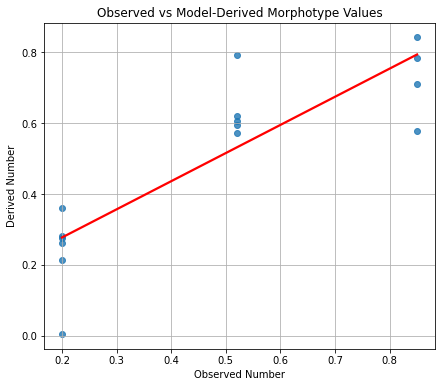

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns

# ------------------------------
# 1. Load observed vs derived data
# ------------------------------
df_obs = pd.read_excel(
    "Morphotypes_Validation.xlsx",
    sheet_name='validation'
)

df_obs['Derived Number'] = df['Morphotypes_Predictor_Score']
df_obs['Derived Morphotypes'] = df['Morphotypes_Class']
# ------------------------------
# 2. Quantitative validation metrics
# ------------------------------
r2 = r2_score(df_obs['Observed Number'], df_obs['Derived Number'])
rmse = np.sqrt(mean_squared_error(df_obs['Observed Number'], df_obs['Derived Number']))
mae = mean_absolute_error(df_obs['Observed Number'], df_obs['Derived Number'])
corr = df_obs['Observed Number'].corr(df_obs['Derived Number'])

print(f"R² = {r2:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAE = {mae:.3f}")
print(f"Correlation = {corr:.3f}")

# ------------------------------
# 3. Scatter plot: Observed vs Derived
# ------------------------------
plt.figure(figsize=(7,6))
sns.regplot(x='Observed Number', y='Derived Number', data=df_obs, ci=None, line_kws={'color':'red'})
plt.title('Observed vs Model-Derived Morphotype Values')
plt.xlabel('Observed Number')
plt.ylabel('Derived Number')
plt.grid(True)
plt.show()

# ------------------------------
# 4. Confusion Matrix (categorical morphotype comparison)
# ------------------------------
#conf_matrix = pd.crosstab(df_obs['Observed Morphotypes'], df_obs['Derived Morphotypes'], normalize='index')

#plt.figure(figsize=(8,6))
#sns.heatmap(conf_matrix, annot=True, fmt=".2f", cmap='Blues')
#plt.title('Morphotype Agreement Matrix (Normalized)')
#plt.ylabel('Observed')
#plt.xlabel('Model Derived')
#plt.show()

# ------------------------------
# 5. Optional: Agreement summary
# ------------------------------
df['Match'] = df_obs['Observed Morphotypes'] == df_obs['Derived Morphotypes']
#accuracy = df_obs['Match'].mean()

#print(f"\nMorphotype categorical agreement: {accuracy*100:.1f}%")
